In [1]:
!pip install graphviz

In [4]:
from graphviz import Digraph

In [5]:
from IPython.display import display

In [9]:
class ASTNode:
    def __init__(self, value, left=None, right=None):
        self.value = value
        self.left = left
        self.right = right

In [10]:
class Parser:
  def __init__(self, expression):
    self.tokens = list(expression.replace(" ", ""))
    self.pos = 0

  def get_next(self):
    if self.pos < len(self.tokens):
      token = self.tokens[self.pos]
      return None

  def eat(self):
    self.pos +=1

  def parser_E(self):
    node = self.parser_T()
    while self.get_next() in ('+', '-'):
      op = self.get_next()
      self.eat()
      right = self.parser_T()
      node = ASTNode(op, node, right)
      return node

  def parser_F(self):
    token = self.get_next()
    if token =='(':
      self.eat()
      node = self.parser_E()
      self.eat()
      return node
    else:
      self.eat()
      return ASTNode(token)

In [11]:
symbol_table = {}

In [12]:
def evaluate(node):
  if node.left is None and node.right is None:
    if node.value.isdigit():
      return int(node.value)
    else:
      if node.value not in symbol_table:
        val = int(input(f"Enter value for {node.value}: "))
        symbol_table[node.value] = val
      return symbol_table[node.value]

      left_val = evaluate(node.left)
      right_val = evaluate(node.right)

      if node.value == '+':
        return left_val + right_val
      elif node.value == '-':
        return left_val - right_val
      elif node.value == '*':
        return left_value *  right_val
      elif node.value == '/':
        return left_val / right_val

In [13]:
def draw_ast(node, graph, parent=None, count=[0]):
  if node is None:
    return

  node_id = str(count[0])
  graph.node(node_id, str(node.value))
  count[0] += 1

  if parent is not None:
    graph.edge(parent, node_id)

  draw_ast(node.left, graph, node_id, count)
  draw_ast(node.right, graph, node_id, count)


In [19]:
expr = input("Enter expression: ")
parser = Parser(expr)
ast_root = parser.parse_E()

dot = Digraph()
draw_ast(ast_root, dot)

display(dot)

print("\nEvaluation:")
result = evaluate(ast_root)
print("\nFinal Result:", result)

Enter expression: a+b*c


UnboundLocalError: cannot access local variable 'node_id' where it is not associated with a value

Enter expression: a+b*c


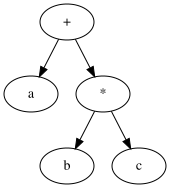


Evaluation:
Enter value for a: 2
Enter value for b: 4
Enter value for c: 1

Final Result: 6


In [22]:
!pip install graphviz

from graphviz import Digraph
# AST Node Class
class ASTNode:
    def __init__(self, value, left=None, right=None):
        self.value = value
        self.left = left
        self.right = right
# Parser
class Parser:
    def __init__(self, expression):
        self.tokens = list(expression.replace(" ", ""))
        self.pos = 0
    def get_next(self):
        if self.pos < len(self.tokens):
            return self.tokens[self.pos]
        return None
    def eat(self):
        self.pos += 1
    def parse_E(self):
        node = self.parse_T()
        while self.get_next() in ('+', '-'):
            op = self.get_next()
            self.eat()
            right = self.parse_T()
            node = ASTNode(op, node, right)
        return node
    def parse_T(self):
        node = self.parse_F()
        while self.get_next() in ('*', '/'):
            op = self.get_next()
            self.eat()
            right = self.parse_F()
            node = ASTNode(op, node, right)
        return node

    def parse_F(self):
        token = self.get_next()
        if token == '(':
            self.eat()
            node = self.parse_E()
            self.eat()
            return node
        else:
            self.eat()
            return ASTNode(token)
# Symbol table
symbol_table = {}
# Evaluate AST
def evaluate(node):
    if node.left is None and node.right is None:
        if node.value.isdigit():
            return int(node.value)
        else:
            if node.value not in symbol_table:
                while True:
                    try:
                        val = int(input(f"Enter value for {node.value}: "))
                        break
                    except ValueError:
                        print("Invalid input. Please enter an integer.")
                symbol_table[node.value] = val
            return symbol_table[node.value]
    left_val = evaluate(node.left)
    right_val = evaluate(node.right)

    if node.value == '+':
        return left_val + right_val
    elif node.value == '-':
        return left_val - right_val
    elif node.value == '*':
        return left_val * right_val
    elif node.value == '/':
        return left_val / right_val
#Draw AST using Graphviz
def draw_ast(node, graph, parent=None, count=[0]):
    if node is None:
        return
    node_id = str(count[0])
    graph.node(node_id, str(node.value))
    count[0] += 1
    if parent is not None:
        graph.edge(parent, node_id)
    draw_ast(node.left, graph, node_id, count)
    draw_ast(node.right, graph, node_id, count)
# USER INPUT
expr = input("Enter expression: ")
parser = Parser(expr)
ast_root = parser.parse_E()
# Draw tree
dot = Digraph()
draw_ast(ast_root, dot)
# Show tree
display(dot)
# Evaluate
print("\nEvaluation:")
result = evaluate(ast_root)
print("\nFinal Result:", result)
